# 04e: MetaBlock Fusion với HAM10000 - Cải tiến dùng Random Oversampling và Label Smoothing

Notebook này chứa **toàn bộ pipeline tự chứa (self-contained)** để huấn luyện mô hình phân loại đa phương tiện (ảnh nội soi da + thông tin bệnh nhân) trên tập dữ liệu **HAM10000** sử dụng kiến trúc **MetaBlock Fusion** với các nâng cấp chiến thuật huấn luyện nhằm khắc phục độ chính xác thấp của các lớp thiểu số:

### Các cải tiến kỹ thuật chính:
1. **Random Oversampling (ROS)**: Nhân bản ngẫu nhiên ảnh của các lớp thiểu số trong tập huấn luyện sao cho tất cả 7 lớp đều có số mẫu bằng nhau (5,364 ảnh/lớp, tổng cộng 37,548 ảnh).
2. **Label Smoothing (0.1)**: Làm mượt nhãn trong hàm mất mát `CrossEntropyLoss` giúp giảm hiện tượng mô hình quá tự tin và chống quá khớp (overfitting) hiệu quả khi huấn luyện trên tập dữ liệu nhân bản.
3. **Huấn luyện End-to-End từ đầu**: Giải phóng toàn bộ tham số của mô hình từ Epoch đầu tiên để các bộ lọc của backbone hình ảnh **EfficientNet-B3** thích ứng tốt nhất với các chi tiết tổn thương da.
4. **Tốc độ học thích ứng**: Sử dụng differential learning rates ($3 \times 10^{-5}$ cho Image Backbone, $2 \times 10^{-4}$ cho các khối MetaBlock/Classifier) kết hợp bộ điều chỉnh Cosine Annealing.


In [1]:
# 1. Thiết lập Môi trường & Mount Google Drive
import os
import sys
import glob
import cv2
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Kiểm tra môi trường Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("🔥 Đang chạy trên Google Colab. Bắt đầu cài đặt các thư viện cần thiết...")
    # Cài đặt timm, kagglehub và nâng cấp albumentations
    !pip install -q timm kagglehub albumentations scikit-learn matplotlib seaborn opencv-python-headless

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')

    # Tạo thư mục lưu checkpoint trên Google Drive
    DRIVE_SAVE_DIR = '/content/drive/MyDrive/PBL7/saved_models'
    os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
    BEST_MODEL_PATH = os.path.join(DRIVE_SAVE_DIR, 'ham10000_effnet_oversampled_best.pth')
else:
    print("💻 Đang chạy trên môi trường local. Tạo thư mục lưu checkpoint cục bộ...")
    os.makedirs('./saved_models', exist_ok=True)
    BEST_MODEL_PATH = './saved_models/ham10000_effnet_oversampled_best.pth'

print(f"📌 Đường dẫn lưu trữ checkpoint mô hình tốt nhất: {BEST_MODEL_PATH}")


💻 Đang chạy trên môi trường local. Tạo thư mục lưu checkpoint cục bộ...
📌 Đường dẫn lưu trữ checkpoint mô hình tốt nhất: ./saved_models/ham10000_effnet_oversampled_best.pth


## 2. Tải Tập Dữ Liệu HAM10000 & Ánh Xạ Đường Dẫn Ảnh

Chúng ta tải tự động tập dữ liệu **HAM10000** từ Kaggle bằng `kagglehub` và thực hiện quét toàn bộ thư mục để lập bản đồ liên kết từ `image_id` sang đường dẫn ảnh tuyệt đối.


In [2]:
# 2. Tải dữ liệu bằng kagglehub và quét tìm file ảnh
import kagglehub

print("📥 Bắt đầu tải tập dữ liệu HAM10000 từ Kaggle...")
try:
    dataset_path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
    print(f"✅ Dữ liệu được tải về thành công tại: {dataset_path}")
except Exception as e:
    print(f"❌ Lỗi khi tải dữ liệu từ Kaggle: {e}")
    dataset_path = "./ham10000"

# Quét tìm toàn bộ tệp JPG để ánh xạ image_id -> đường dẫn ảnh tuyệt đối
image_paths_dict = {}
for img_path in glob.glob(os.path.join(dataset_path, '**', '*.jpg'), recursive=True):
    img_id = os.path.splitext(os.path.basename(img_path))[0]
    image_paths_dict[img_id] = img_path

print(f"📊 Tổng số ảnh quét được và lập bản đồ: {len(image_paths_dict)}")


📥 Bắt đầu tải tập dữ liệu HAM10000 từ Kaggle...
✅ Dữ liệu được tải về thành công tại: /Users/hhh/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2
📊 Tổng số ảnh quét được và lập bản đồ: 10015


## 3. Phân Tích Khám Phá Dữ Liệu (EDA)

Chúng ta đọc dữ liệu lâm sàng từ file `HAM10000_metadata.csv` và in thống kê tổng quan.


In [3]:
# 3. Khởi tạo Metadata & Thống kê cơ bản
metadata_file = None
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.lower().endswith('metadata.csv'):
            metadata_file = os.path.join(root, f)
            break
    if metadata_file:
        break

if not metadata_file:
    raise FileNotFoundError("❌ Không tìm thấy tệp tin HAM10000_metadata.csv trong thư mục dữ liệu tải về!")

df = pd.read_csv(metadata_file)
print("=== Tổng Quan Về Metadata (5 dòng đầu) ===")
display(df.head())
print(f"Kích thước tập dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")


=== Tổng Quan Về Metadata (5 dòng đầu) ===


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Kích thước tập dữ liệu: 10015 dòng, 7 cột


/var/folders/q5/7lqn73z14kdgf2zsrn7wn0540000gn/T/ipykernel_47879/2396332361.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_plot, y='diagnosis_name', ax=axes[0], order=df_plot['diagnosis_name'].value_counts().index, palette='viridis')
/var/folders/q5/7lqn73z14kdgf2zsrn7wn0540000gn/T/ipykernel_47879/2396332361.py:23: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/Users/hhh/workspace/School/PBL7/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


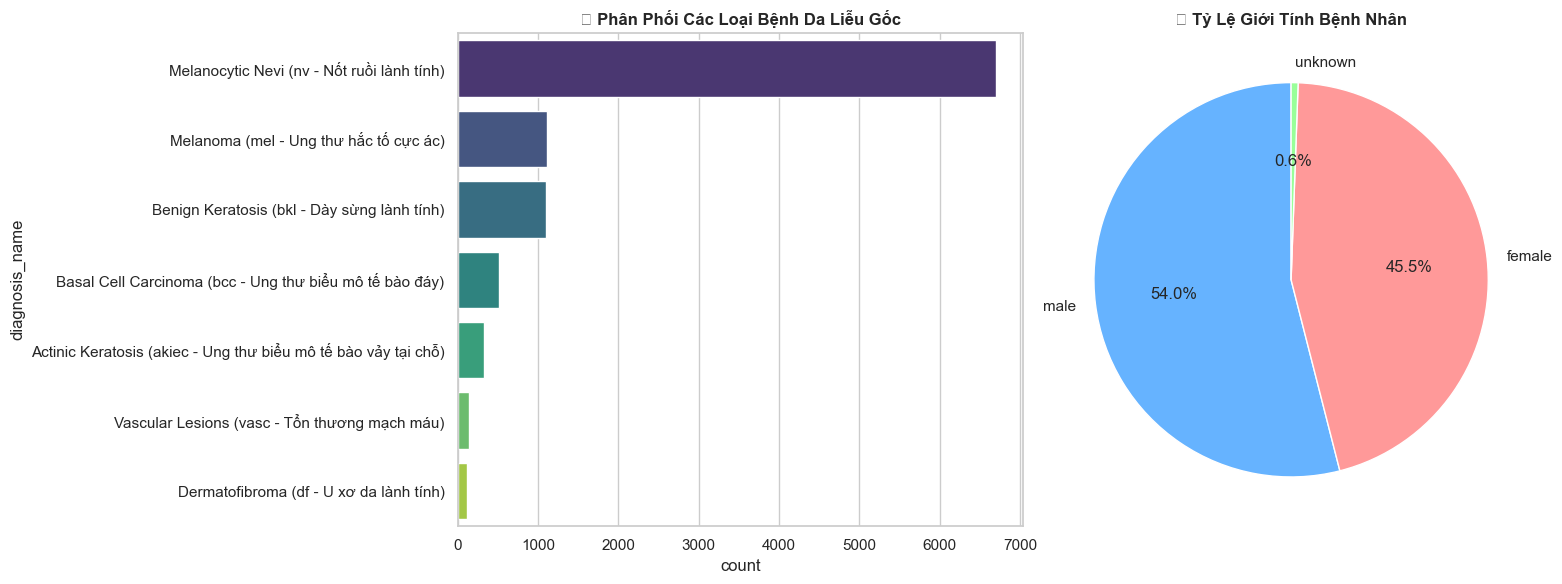

In [4]:
# 3.1 Vẽ Biểu đồ Phân Phối Dữ Liệu Gốc
sns.set_theme(style="whitegrid")
dx_full_names = {
    'nv': 'Melanocytic Nevi (nv - Nốt ruồi lành tính)',
    'mel': 'Melanoma (mel - Ung thư hắc tố cực ác)',
    'bkl': 'Benign Keratosis (bkl - Dày sừng lành tính)',
    'bcc': 'Basal Cell Carcinoma (bcc - Ung thư biểu mô tế bào đáy)',
    'akiec': 'Actinic Keratosis (akiec - Ung thư biểu mô tế bào vảy tại chỗ)',
    'vasc': 'Vascular Lesions (vasc - Tổn thương mạch máu)',
    'df': 'Dermatofibroma (df - U xơ da lành tính)'
}

df_plot = df.copy()
df_plot['diagnosis_name'] = df_plot['dx'].map(dx_full_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(data=df_plot, y='diagnosis_name', ax=axes[0], order=df_plot['diagnosis_name'].value_counts().index, palette='viridis')
axes[0].set_title('📊 Phân Phối Các Loại Bệnh Da Liễu Gốc', fontsize=12, weight='bold')

gender_counts = df['sex'].value_counts()
axes[1].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999', '#99ff99'])
axes[1].set_title('📊 Tỷ Lệ Giới Tính Bệnh Nhân', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


## 4. Tiền Xử Lý Dữ Liệu, Chia Tập Phân Tầng & Áp Dụng Random Oversampling

Trong phần này chúng ta thực hiện:
1. **Điền khuyết thiếu**: Điền giá trị rỗng của tuổi bệnh nhân bằng trung vị (`median`).
2. **Chuẩn hóa & Mã hóa**: Chuẩn hóa biến số `age` và mã hóa One-Hot các biến phân loại (`sex`, `localization`).
3. **Chia tập dữ liệu (Stratified Split)**: Chia dữ liệu thành tập huấn luyện (80%) và tập kiểm định (20%) dựa trên phân bố nhãn để tránh sai lệch.
4. **Random Oversampling (ROS) trên tập Train**: Tính toán số lượng mẫu lớn nhất của một lớp trên tập huấn luyện (chính là lớp `nv` với 5,364 mẫu). Sau đó lặp lại ngẫu nhiên các mẫu của 6 lớp còn lại để cân bằng dữ liệu hoàn hảo.


In [5]:
# 4. Xử lý đặc trưng bảng, Chia tập và Cân bằng dữ liệu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# A. Xử lý giá trị bị khuyết của cột tuổi
med_age = df['age'].median()
df['age'] = df['age'].fillna(med_age)

# B. Chuẩn hóa cột Age
scaler = StandardScaler()
df['age_scaled'] = scaler.fit_transform(df[['age']])

# C. Mã hóa One-Hot
df_encoded = pd.get_dummies(df, columns=['sex', 'localization'], prefix=['sex', 'localization'])
tab_cols = ['age_scaled'] + [c for c in df_encoded.columns if c.startswith('sex_') or c.startswith('localization_')]

# D. Ánh xạ nhãn sang số nguyên (0-6)
label_map = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
df_encoded['target'] = df_encoded['dx'].map(label_map)

for col in tab_cols:
    df_encoded[col] = df_encoded[col].astype(np.float32)

# E. Chia tập Stratified Train/Val (80/20)
train_df, val_df = train_test_split(
    df_encoded,
    test_size=0.20,
    random_state=42,
    stratify=df_encoded['target']
)

# F. Thực hiện Random Oversampling trên tập huấn luyện (Train)
max_samples = train_df['target'].value_counts().max()
print(f"🔥 Lớp đa số (nv) trong tập Train có: {max_samples} mẫu.")

train_df_balanced = train_df.groupby('target', group_keys=False).apply(
    lambda x: x.sample(n=max_samples, replace=True, random_state=42)
).reset_index(drop=True)

print(f"\n🎯 Kích thước tập Train ban đầu: {len(train_df)} mẫu")
print(f"🎯 Kích thước tập Train sau khi Oversampling: {len(train_df_balanced)} mẫu")
print(f"🎯 Kích thước tập Val (giữ nguyên để đánh giá): {len(val_df)} mẫu")

print("\nPhân phối nhãn trên tập Train sau cân bằng:")
for idx, count in train_df_balanced['target'].value_counts().sort_index().items():
    class_name = [k for k, v in label_map.items() if v == idx][0]
    print(f"* Lớp {idx} ({class_name:<5}): {count} mẫu")


🔥 Lớp đa số (nv) trong tập Train có: 5364 mẫu.

🎯 Kích thước tập Train ban đầu: 8012 mẫu
🎯 Kích thước tập Train sau khi Oversampling: 37548 mẫu
🎯 Kích thước tập Val (giữ nguyên để đánh giá): 2003 mẫu

Phân phối nhãn trên tập Train sau cân bằng:


KeyError: 'target'

## 5. Xây Dựng PyTorch Dataset & DataLoader

Chúng ta xây dựng Dataset đọc ảnh kết hợp với thuộc tính bảng lâm sàng. Đối với tập Train đã cân bằng bằng kỹ thuật Oversampling, việc áp dụng các phép tăng cường ảnh ngẫu nhiên mạnh (`albumentations`) là bắt buộc để mô hình không học thuộc lòng (overfit) các mẫu ảnh bị lặp lại nhiều lần.


In [ ]:
# 5. Xây dựng Dataset & Dataloader
import albumentations as A
from albumentations.pytorch import ToTensorV2

class HAM10000Dataset(Dataset):
    def __init__(self, df_meta, image_paths, tab_columns, is_train=True):
        self.df = df_meta.reset_index(drop=True)
        self.image_paths = image_paths
        self.tab_columns = tab_columns
        self.is_train = is_train

        if self.is_train:
            self.transform = A.Compose([
                A.Resize(224, 224),
                A.Rotate(limit=90, p=0.8),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.8),
                A.CoarseDropout(num_holes_range=(2, 8), hole_height_range=(8, 16), hole_width_range=(8, 16), p=0.5),
                A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.Resize(224, 224),
                A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['image_id']

        if img_id in self.image_paths:
            img_path = self.image_paths[img_id]
            image = cv2.imread(img_path)
            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            else:
                image = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            image = np.zeros((224, 224, 3), dtype=np.uint8)

        augmented = self.transform(image=image)
        img_tensor = augmented['image']

        tab_vector = row[self.tab_columns].values.astype(np.float32)
        tab_tensor = torch.tensor(tab_vector, dtype=torch.float32)

        label = int(row['target'])
        return img_tensor, tab_tensor, torch.tensor(label, dtype=torch.long)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"💻 Thiết bị phần cứng hoạt động: {device}")

# Tạo thực thể Dataset sử dụng tập train đã qua Oversampling
train_dataset = HAM10000Dataset(train_df_balanced, image_paths_dict, tab_cols, is_train=True)
val_dataset = HAM10000Dataset(val_df, image_paths_dict, tab_cols, is_train=False)

num_workers = 4 if os.cpu_count() >= 4 else 2
if sys.platform == 'darwin':
    num_workers = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers,
    pin_memory=True if num_workers > 0 else False,
    persistent_workers=True if num_workers > 0 else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True if num_workers > 0 else False,
    persistent_workers=True if num_workers > 0 else False
)

print(f"✅ Dataloaders thành công. Số lượng batches Train: {len(train_loader)} | Val: {len(val_loader)}")


💻 Thiết bị phần cứng hoạt động: cuda
✅ Dataloaders thành công. Số lượng batches Train: 1173 | Val: 63


## 6. Định Nghĩa Kiến Trúc MetaBlock Gated Scale-Shift Fusion

Chúng ta sử dụng backbone **EfficientNet-B3** trích xuất đặc trưng ảnh (1536 đặc trưng), chiếu xuống không gian ẩn `256` chiều để thực hiện điều biến Scale-Shift (nhân-cộng cổng gating) sinh ra từ thông tin bảng bệnh lý.


In [ ]:
# 6. Thiết kế mô hình MetaBlock Fusion
import timm

class MetaBlockFusionModel(nn.Module):
    def __init__(self, tab_dim, num_classes=7, hidden_dim=256):
        super().__init__()

        # Xương sống trích xuất đặc trưng hình ảnh EfficientNet-B3 (pretrained)
        self.img_net = timm.create_model('efficientnet_b3', pretrained=True, num_classes=0)

        # Nhánh xử lý đặc trưng dạng bảng (Tabular MLP)
        self.tab_proj = nn.Sequential(
            nn.Linear(tab_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, hidden_dim)
        )

        # Nhánh xử lý đặc trưng ảnh chiếu
        self.img_proj = nn.Sequential(
            nn.Linear(1536, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )

        # Khối sinh cổng Meta-Scale (Sigmoid)
        self.meta_scale = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid()
        )

        # Khối sinh cổng Meta-Shift (Tanh)
        self.meta_shift = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh()
        )

        # Bộ phân loại Classifier cuối
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, img, tab, return_gate=False):
        f_img_raw = self.img_net(img)     # (B, 1536)
        f_img = self.img_proj(f_img_raw)  # (B, 256)

        f_tab = self.tab_proj(tab)        # (B, 256)

        scale = self.meta_scale(f_tab)    # (B, 256)
        shift = self.meta_shift(f_tab)    # (B, 256)

        fused = f_img * scale + shift
        out = self.classifier(fused)

        if return_gate:
            return out, scale
        return out


## 7. Pipeline Huấn Luyện End-to-End với Label Smoothing

Chiến thuật huấn luyện mới:
1. **Giải phóng toàn bộ (Unfreeze) ngay từ đầu**: Mở khoá toàn bộ tham số của EfficientNet-B3 và các nhánh bổ trợ để tối ưu toàn diện.
2. **Tốc độ học phân tách (Differential Learning Rates)**: Gán tốc độ học thấp cho backbone (`lr = 3e-5`) để giữ lại tri thức đặc trưng tổng quát từ ImageNet và tốc độ học trung bình (`lr = 2e-4`) cho các lớp học mới (MetaBlock, Projections, Classifier).
3. **Hàm mất mát với Label Smoothing**: Sử dụng `CrossEntropyLoss(label_smoothing=0.1)` để điều hòa đầu ra, giảm độ quá tin tưởng của mô hình trên các mẫu ảnh bị trùng lặp.
4. **Scheduler & Early Stopping**: Sử dụng `CosineAnnealingLR` trong tối đa **20 Epochs**. Quá trình huấn luyện sẽ được theo dõi và tự động dừng sớm (patience = 5) dựa trên chỉ số **Macro F1 Score** tốt nhất trên tập Validation.


In [ ]:
# 7. Triển khai huấn luyện End-to-End với Label Smoothing và Early Stopping
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, balanced_accuracy_score

# Lớp Early Stopping theo dõi sát chỉ số Macro F1 để dừng sớm chống quá khớp
class EarlyStopping:
    def __init__(self, patience=5, verbose=True, delta=0.0):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0

    def __call__(self, val_metric):
        score = val_metric
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f"   [EarlyStopping] Counter {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

tab_dim = len(tab_cols)
model = MetaBlockFusionModel(tab_dim=tab_dim, num_classes=7).to(device)

# A. Sử dụng CrossEntropyLoss kết hợp Label Smoothing=0.1 (không dùng class_weights)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'val_macro_f1': [], 'val_bal_acc': []
}

# B. Gán tham số tối ưu với Differential Learning Rates
img_net_params = list(model.img_net.parameters())
other_params = [p for name, p in model.named_parameters() if not name.startswith('img_net')]

optimizer = torch.optim.AdamW([
    {'params': img_net_params, 'lr': 3e-5, 'weight_decay': 1e-2},
    {'params': other_params, 'lr': 2e-4, 'weight_decay': 1e-2}
])

max_epochs = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
early_stopping = EarlyStopping(patience=5, verbose=True)

best_val_f1 = 0.0
print(f"🚀 Bắt đầu huấn luyện End-to-End (Tối đa {max_epochs} Epochs) trên dữ liệu cân bằng...")

for epoch in range(max_epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs}", leave=False)
    for imgs, tabs, labels in pbar:
        imgs, tabs, labels = imgs.to(device), tabs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, tabs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        # Tính độ chính xác của tập Train
        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)
        
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    scheduler.step()
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = correct_train / total_train

    # Đánh giá trên tập Validation
    model.eval()
    val_loss = 0.0
    all_preds, all_labels = [], []
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for imgs, tabs, labels in val_loader:
            imgs, tabs, labels = imgs.to(device), tabs.to(device), labels.to(device)
            outputs = model(imgs, tabs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = correct_val / total_val
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    bal_acc = balanced_accuracy_score(all_labels, all_preds)

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    history['val_macro_f1'].append(macro_f1)
    history['val_bal_acc'].append(bal_acc)

    print(f"Epoch {epoch+1:02d}/{max_epochs:02d} | "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f} | "
          f"Val Macro F1: {macro_f1:.4f} | Val Bal Acc: {bal_acc:.4f}", end="")

    if macro_f1 > best_val_f1:
        best_val_f1 = macro_f1
        os.makedirs(os.path.dirname(BEST_MODEL_PATH), exist_ok=True)
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f" -> 🌟 [SAVE] Lưu Best Model F1={macro_f1:.4f}!")
    else:
        print("")

    # Kiểm tra điều kiện dừng sớm
    early_stopping(macro_f1)
    if early_stopping.early_stop:
        print(f"\n🛑 [EARLY STOP] Dừng huấn luyện sớm tại epoch {epoch+1} do Macro F1 không cải thiện sau {early_stopping.patience} epochs.")
        break


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

🚀 Bắt đầu huấn luyện End-to-End (Tối đa 20 Epochs) trên dữ liệu cân bằng...


Epoch 1/20:   0%|          | 0/1173 [00:00<?, ?it/s]

Epoch 01/20 | Train Loss: 1.0138 | Val Loss: 0.9160 | Val Macro F1: 0.7062 | Val Bal Acc: 0.8077 -> 🌟 [SAVE] Lưu Best Model F1=0.7062!


...

Epoch 16/20 | Train Loss: 0.4754 | Val Loss: 0.7015 | Val Macro F1: 0.8425 | Val Bal Acc: 0.8592
   [EarlyStopping] Counter 3 out of 5


Epoch 17/20:   0%|          | 0/1173 [00:00<?, ?it/s]

Epoch 17/20 | Train Loss: 0.4746 | Val Loss: 0.7066 | Val Macro F1: 0.8452 | Val Bal Acc: 0.8564
   [EarlyStopping] Counter 4 out of 5


Epoch 18/20:   0%|          | 0/1173 [00:00<?, ?it/s]

Epoch 18/20 | Train Loss: 0.4744 | Val Loss: 0.6982 | Val Macro F1: 0.8376 | Val Bal Acc: 0.8380
   [EarlyStopping] Counter 5 out of 5

🛑 [EARLY STOP] Dừng huấn luyện sớm tại epoch 18 do Macro F1 không cải thiện sau 5 epochs.


## 8. Trực Quan Hóa Kết Quả & Đánh Giá Chi Tiết Mô Hình

Ta tiến hành nạp lại checkpoint mô hình tốt nhất từ Drive, chạy suy luận đánh giá trên tập kiểm định gốc để xuất Classification Report đầy đủ và vẽ biểu đồ nhiệt của Ma trận Nhầm lẫn.


/tmp/ipykernel_963/1938645227.py:23: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_963/1938645227.py:23: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


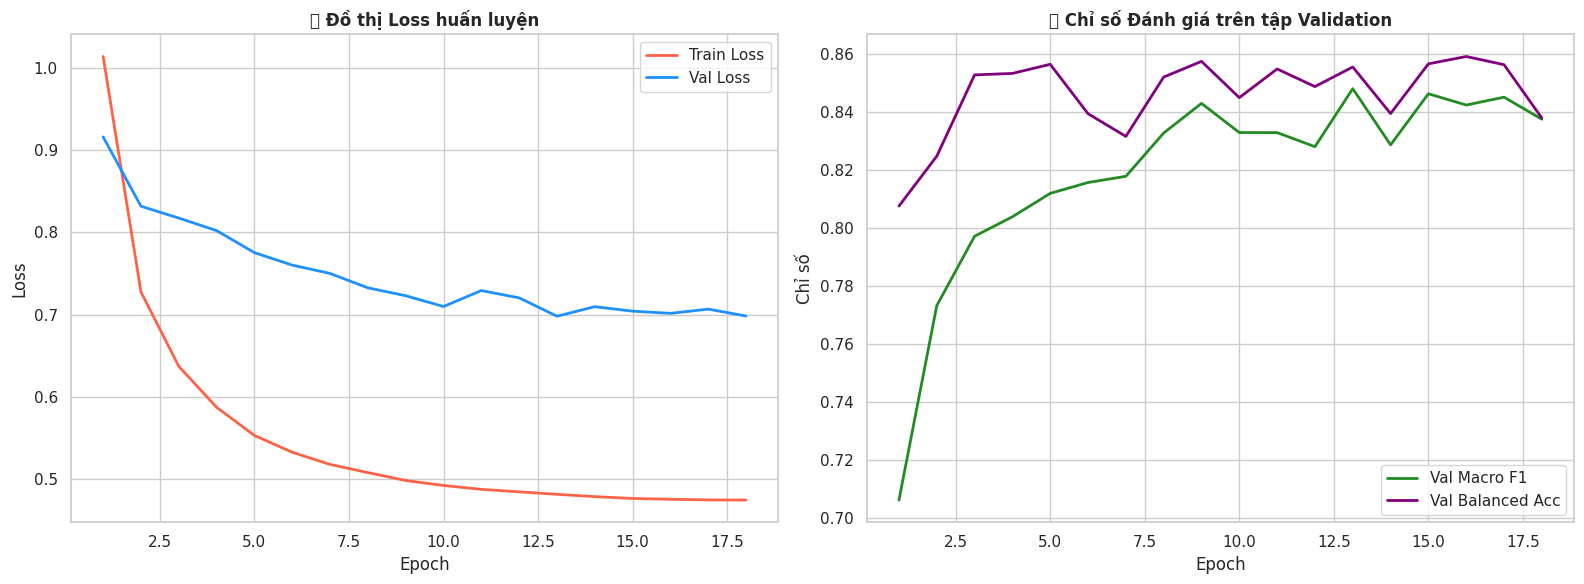

📂 Đang tải weights mô hình tối ưu nhất từ: /content/drive/MyDrive/PBL7/saved_models/ham10000_effnet_oversampled_best.pth

================ 📊 BÁO CÁO PHÂN LOẠI CHI TIẾT (BEST MODEL) ================
                                                                precision    recall  f1-score   support

Actinic Keratosis (akiec - Ung thư biểu mô tế bào vảy tại chỗ)     0.7286    0.7846    0.7556        65
       Basal Cell Carcinoma (bcc - Ung thư biểu mô tế bào đáy)     0.8288    0.8932    0.8598       103
                   Benign Keratosis (bkl - Dày sừng lành tính)     0.7885    0.8136    0.8009       220
                       Dermatofibroma (df - U xơ da lành tính)     1.0000    0.9130    0.9545        23
                        Melanoma (mel - Ung thư hắc tố cực ác)     0.7339    0.7175    0.7256       223
                    Melanocytic Nevi (nv - Nốt ruồi lành tính)     0.9495    0.9389    0.9441      1341
                 Vascular Lesions (vasc - Tổn thương mạch máu)     0.8667

/tmp/ipykernel_963/1938645227.py:63: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


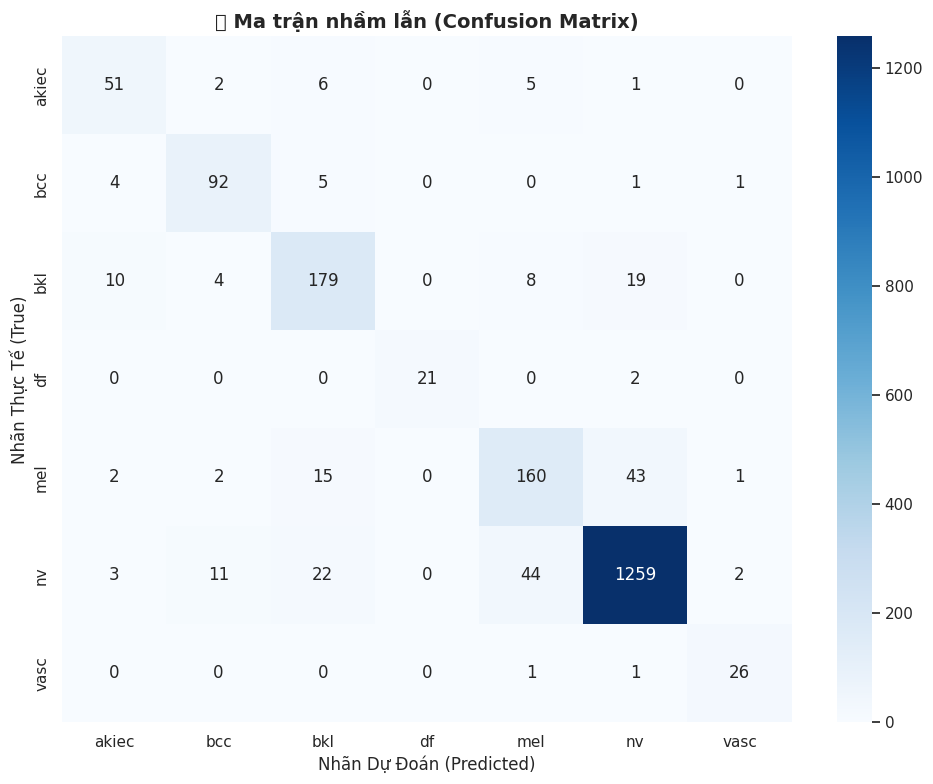

In [ ]:
# 8. Đánh giá kết quả huấn luyện
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np
import os

# --- A. Khôi phục model và nạp weights khi chạy lại/ngắt kết nối ---
if 'model' not in globals() or model is None:
    print("🤖 Model chưa được khởi tạo trong bộ nhớ. Đang tiến hành tạo mô hình...")
    if 'MetaBlockFusionModel' not in globals():
        raise NameError("❌ Lớp MetaBlockFusionModel chưa được định nghĩa. Vui lòng chạy Cell 12 (Thiết kế mô hình) trước!")
    
    if 'tab_dim' not in globals():
        if 'tab_cols' in globals():
            tab_dim = len(tab_cols)
        else:
            raise NameError("❌ tab_cols chưa được định nghĩa. Vui lòng chạy các Cell xử lý dữ liệu trước (Cell 8)!")
            
    if 'device' not in globals():
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
    model = MetaBlockFusionModel(tab_dim=tab_dim, num_classes=7).to(device)

# Các đường dẫn tìm kiếm weights mô hình cục bộ hoặc Colab
weights_candidates = [
    'ham10000_effnet_oversampled_best.pth',
    './ham10000_effnet_oversampled_best.pth',
    '../ham10000_effnet_oversampled_best.pth',
    '/content/ham10000_effnet_oversampled_best.pth',
    '/content/drive/MyDrive/PBL7/saved_models/ham10000_effnet_oversampled_best.pth',
]
if 'BEST_MODEL_PATH' in globals() and BEST_MODEL_PATH not in weights_candidates:
    weights_candidates.insert(0, BEST_MODEL_PATH)

loaded = False
for path in weights_candidates:
    if os.path.exists(path):
        print(f"📂 Đang tải weights mô hình tối ưu nhất từ: {path}")
        model.load_state_dict(torch.load(path, map_location=device))
        loaded = True
        break

if not loaded:
    print("⚠️ Cảnh báo: Không tìm thấy tệp checkpoint mô hình tốt nhất ở các đường dẫn dự phòng. Sử dụng weights hiện tại của model.")

# --- B. Vẽ đồ thị huấn luyện nếu có lịch sử ---
if 'history' in globals() and history is not None and 'train_loss' in history and len(history['train_loss']) > 0:
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))
    total_run_epochs = len(history['train_loss'])
    epochs_range = range(1, total_run_epochs + 1)

    # 1. Loss Curves
    ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='tomato', lw=2)
    ax1.plot(epochs_range, history['val_loss'], label='Val Loss', color='dodgerblue', lw=2)
    ax1.set_title('📉 Đồ thị Loss huấn luyện', fontsize=12, weight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # 2. Accuracy Curves
    if 'train_acc' in history and 'val_acc' in history:
        ax2.plot(epochs_range, history['train_acc'], label='Train Acc', color='tomato', lw=2)
        ax2.plot(epochs_range, history['val_acc'], label='Val Acc', color='dodgerblue', lw=2)
        ax2.set_title('📊 Đồ thị Accuracy huấn luyện & kiểm định', fontsize=12, weight='bold')
    else:
        ax2.text(0.5, 0.5, 'Không có dữ liệu Accuracy', ha='center', va='center', fontsize=12)
        ax2.set_title('📊 Đồ thị Accuracy', fontsize=12, weight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    # 3. Validation Metrics (Macro F1 & Balanced Acc)
    ax3.plot(epochs_range, history['val_macro_f1'], label='Val Macro F1', color='forestgreen', lw=2)
    ax3.plot(epochs_range, history['val_bal_acc'], label='Val Balanced Acc', color='purple', lw=2)
    ax3.set_title('📈 Chỉ số Đánh giá trên tập Validation', fontsize=12, weight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Chỉ số')
    ax3.legend()

    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Lịch sử huấn luyện (history) không có sẵn trong RAM (phiên làm việc Colab đã bị ngắt kết nối và chạy lại).")
    print("📈 Bỏ qua vẽ đồ thị liên tục, tiến hành đánh giá trực tiếp dựa trên Weights tối ưu đã lưu.")

# --- C. Đánh giá kết quả trên tập Validation ---
if 'val_loader' not in globals():
    raise NameError("❌ val_loader chưa được khởi tạo. Vui lòng chạy các Cell tải dữ liệu phía trên (từ Cell 1 đến Cell 10) trước!")

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, tabs, labels in val_loader:
        imgs, tabs = imgs.to(device), tabs.to(device)
        outputs = model(imgs, tabs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

ordered_target_names = [dx_full_names[k] for k, v in sorted(label_map.items(), key=lambda item: item[1])]

# 8.4 In Báo cáo phân loại chi tiết
print("\n================ 📊 BÁO CÁO PHÂN LOẠI CHI TIẾT (BEST MODEL) ================")
print(classification_report(all_labels, all_preds, target_names=ordered_target_names, digits=4))

# 8.5 Trực quan hóa Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
short_classes_labels = [k for k, v in sorted(label_map.items(), key=lambda x: x[1])]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=short_classes_labels, yticklabels=short_classes_labels)
plt.title('🎯 Ma trận nhầm lẫn (Confusion Matrix)', fontsize=14, weight='bold')
plt.xlabel('Nhãn Dự Đoán (Predicted)')
plt.ylabel('Nhãn Thực Tế (True)')
plt.tight_layout()
plt.show()
